In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import os

In [6]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [7]:
data_dir = "/Users/aakashrajput/MachineLearning/ng_exoplaner/Downloads"

In [8]:
all_csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

In [9]:
num_files = len(all_csv_files)

In [10]:
num_files

713

In [11]:
if num_files==0:
    print("Error: NO CSV files found")
    exit()

In [12]:
summary_file = "/Users/aakashrajput/MachineLearning/ng_exoplaner/psg_models.csv"


In [13]:
planet_id_column = "PlanetIndex"

In [14]:
target_parameters = ['H2O','CO2','O2','N2','CH4','N2O','CO','O3','SO2','NH3','C2H6','NO2','planet_density','star_temperature_in_Kelvin']
spectrum_length = 4379

In [15]:
dropout_rate = 0.3
learning_rate = 0.005
batch_size = 16
num_epochs = 30
patience = 15
num_mc_samples = 300

In [16]:
summary_df = pd.read_csv(summary_file)

In [17]:
summary_df[planet_id_column]= summary_df[planet_id_column].astype(str)

In [18]:
x_data = []
y_data = []

In [19]:
x_data = []
y_data = []


summary_df = summary_df.drop_duplicates(subset=[planet_id_column])
summary_df = summary_df.reset_index(drop=True)

for index, row in summary_df.iterrows():

    try:
        
        planet_id = str(row[planet_id_column]).split('.')[0].zfill(7)

        file_path = os.path.join(data_dir, f"{planet_id}.csv")

        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)

        # spectrum
        spectrum = pd.to_numeric(df['planet_signal_(erg/s/cm2)'], errors='coerce').values
        spectrum = np.nan_to_num(spectrum)

        
        if len(spectrum) > 4379:
            spectrum = spectrum[:4379]
        elif len(spectrum) < 4379:
            spectrum = np.pad(spectrum, (0, 4379 - len(spectrum)))
        # targets
        targets = pd.to_numeric(row[target_parameters], errors='coerce').values
        targets = np.nan_to_num(targets)

        x_data.append(spectrum)
        y_data.append(targets)

    except Exception as e:
        print("Error:", e)
        continue

print("Loaded planets:", len(x_data))

Loaded planets: 713


In [20]:
from sklearn.preprocessing import StandardScaler

X = np.array(x_data)
y = np.array(y_data)

y = y[:, :12]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val   = scaler_X.transform(X_val)
X_test  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_val   = scaler_y.transform(y_val)
y_test  = scaler_y.transform(y_test)
print(np.mean(X), np.std(X))

X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y, dtype=torch.float32)

0.7791871660049928 0.49980513638230045


In [21]:

#convert to tensors AFTER split
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=16)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=1)

In [22]:
import torch.nn.functional as F

class INARA(nn.Module):
    def __init__(self, input_len, output_dim):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 32, 5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, 5, padding=2)

        self.pool = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()

        # FIXED flatten calculation
        dummy = torch.randn(1, 1, input_len)
        x = self.pool(F.leaky_relu(self.conv1(dummy), 0.1))
        x = self.pool(F.leaky_relu(self.conv2(x), 0.1))
        x = self.pool(F.leaky_relu(self.conv3(x), 0.1))

        flat_size = x.view(1, -1).shape[1]

        self.fc1 = nn.Linear(flat_size, 128)
       self.dropout = nn.Dropout(0.05)
        self.fc2 = nn.Linear(128, output_dim)

    def forward(self, x):
        #x = x.permute(0, 2, 1)

        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))

        x = self.flatten(x)
        x = F.leaky_relu(self.fc1(x), 0.1)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = INARA(X_train.shape[2], y_train.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), learning_rate)
loss_fn = nn.L1Loss()

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        
        optimizer.step()

        train_loss += loss.item()

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += loss_fn(pred, yb).item()
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

Epoch 1 | Train: 1.3448 | Val: 0.7630
Epoch 2 | Train: 1.0542 | Val: 0.7649
Epoch 3 | Train: 0.9226 | Val: 0.7635
Epoch 4 | Train: 0.7902 | Val: 0.7546
Epoch 5 | Train: 0.7865 | Val: 0.7543
Epoch 6 | Train: 0.7868 | Val: 0.7553
Epoch 7 | Train: 0.7879 | Val: 0.7596
Epoch 8 | Train: 0.7892 | Val: 0.7572
Epoch 9 | Train: 0.7876 | Val: 0.7555
Epoch 10 | Train: 0.7871 | Val: 0.7583
Epoch 11 | Train: 0.7886 | Val: 0.7586
Epoch 12 | Train: 0.7880 | Val: 0.7587
Epoch 13 | Train: 0.7885 | Val: 0.7547
Epoch 14 | Train: 0.7864 | Val: 0.7552
Epoch 15 | Train: 0.7856 | Val: 0.7595
Epoch 16 | Train: 0.7870 | Val: 0.7556
Epoch 17 | Train: 0.7879 | Val: 0.7543
Epoch 18 | Train: 0.7854 | Val: 0.7544
Epoch 19 | Train: 0.7851 | Val: 0.7545
Epoch 20 | Train: 0.7852 | Val: 0.7547
Epoch 21 | Train: 0.7860 | Val: 0.7553
Epoch 22 | Train: 0.7851 | Val: 0.7546
Epoch 23 | Train: 0.7857 | Val: 0.7541
Epoch 24 | Train: 0.7864 | Val: 0.7549
Epoch 25 | Train: 0.7861 | Val: 0.7547
Epoch 26 | Train: 0.7864 | Val: 0.

In [24]:
model.train()  # keep dropout ON

mc_samples = 100

all_means = []
all_stds = []

with torch.no_grad():
    for xb, _ in test_loader:

        xb = xb.to(device)

        preds = []

        for _ in range(mc_samples):
            pred = model(xb)
            preds.append(pred.cpu().numpy())

        preds = np.array(preds).squeeze(1)

        mean = preds.mean(axis=0)
        std = preds.std(axis=0)

        all_means.append(mean)
        all_stds.append(std)

print("MC Dropout done")

MC Dropout done


In [25]:
torch.save(model.state_dict(), "inara_model.pth")

In [26]:
test_file = r"/Users/aakashrajput/MachineLearning/ng_exoplaner/Downloads/0285055.csv"

In [27]:
df = pd.read_csv(test_file)

spectrum = pd.to_numeric(df['planet_signal_(erg/s/cm2)'], errors='coerce').values
spectrum = np.nan_to_num(spectrum)

if len(spectrum)>4379:
    spectrum = spectrum[:4379]
elif len(spectrum)<4379:
    spectrum = np.pad(spectrum,(0, 4379 - len(spectrum)))

spectrum = scaler_X.transform([spectrum])
test_tensor = torch.tensor(spectrum, dtype=torch.float32)
test_tensor = test_tensor.unsqueeze(1).to(device)

In [28]:
model.train()  

predictions = []

for _ in range(100):
    pred = model(test_tensor)
    predictions.append(pred.detach().numpy())

predictions = np.array(predictions)

mean_pred = predictions.mean(axis=0)
std_pred = predictions.std(axis=0)

In [29]:
mean_pred = scaler_y.inverse_transform(mean_pred)
std_pred = std_pred * scaler_y.scale_


In [30]:
for i, gas in enumerate(target_parameters[:12]):
    print(f"{gas}: {mean_pred[0][i]:.4f} ± {std_pred[0][i]:.4f}")

H2O: 0.0574 ± 0.0000
CO2: 0.3572 ± 0.0000
O2: 0.3397 ± 0.0000
N2: 0.1913 ± 0.0000
CH4: 0.0360 ± 0.0000
N2O: 0.0077 ± 0.0000
CO: 0.0072 ± 0.0000
O3: 0.0014 ± 0.0000
SO2: 0.0070 ± 0.0000
NH3: 0.0030 ± 0.0000
C2H6: 0.0001 ± 0.0000
NO2: 0.0000 ± 0.0000


In [31]:
from sklearn.metrics import mean_squared_error

model.eval()

    "y_pred = model(X_test.to(device)).detach().cpu().numpy()\n",

y_pred = scaler_y.inverse_transform(y_pred)
y_true = scaler_y.inverse_transform(y_test.cpu().numpy())

mse = mean_squared_error(y_true[:, :12], y_pred[:, :12])
print("MSE:", mse)

MSE: 0.0003493181138765067


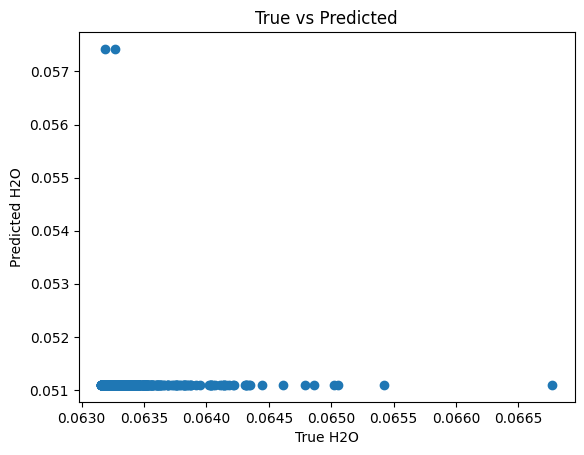

In [32]:
import matplotlib.pyplot as plt

plt.scatter(y_true[:,0], y_pred[:,0])
plt.xlabel("True H2O")
plt.ylabel("Predicted H2O")
plt.title("True vs Predicted")
plt.show()

In [33]:
with torch.no_grad():
    print(model(X_train[:5]))

tensor([[-0.3161,  0.1092,  0.0245,  0.0497, -0.1128,  0.0864, -0.1090, -0.1639,
         -0.0941,  0.0183, -0.3013, -0.0974],
        [-0.3161,  0.1092,  0.0245,  0.0497, -0.1128,  0.0864, -0.1090, -0.1639,
         -0.0941,  0.0183, -0.3013, -0.0974],
        [-0.3161,  0.1092,  0.0245,  0.0497, -0.1128,  0.0864, -0.1090, -0.1639,
         -0.0941,  0.0183, -0.3013, -0.0974],
        [-0.3161,  0.1092,  0.0245,  0.0497, -0.1128,  0.0864, -0.1090, -0.1639,
         -0.0941,  0.0183, -0.3013, -0.0974],
        [-0.3161,  0.1092,  0.0245,  0.0497, -0.1128,  0.0864, -0.1090, -0.1639,
         -0.0941,  0.0183, -0.3013, -0.0974]])
